# MEMIT Baseline Reproduction — NLP Project


## 1. Check GPU

In [ ]:
!nvidia-smi

Sun Apr 12 02:13:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Clone MEMIT Repository


**Cleans up any previous clones and start fresh.**

In [ ]:
%cd /content
!rm -rf memit
!git clone https://github.com/kmeng01/memit.git
%cd memit
!pwd

/content
Cloning into 'memit'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 196 (delta 47), reused 40 (delta 40), pack-reused 99 (from 1)
Receiving objects: 100% (196/196), 134.90 KiB | 16.86 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/memit
/content/memit


## 3. Install Dependencies

In [ ]:
!pip install -q matplotlib scipy datasets
!pip install -q transformers==4.40.2 datasets accelerate tokenizers
!pip install -q torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 155.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.


## 4. Compatibility Patches

The MEMIT codebase was written for older versions of PyTorch and HuggingFace Transformers.
These patches fix two compatibility issues:

1. **`nethook.py`** — In PyTorch 2.x, forward hooks on Linear layers can receive empty positional `inputs` when the module uses keyword arguments internally. We add `with_kwargs=True` support so the hook can capture inputs passed as kwargs.

2. **`repr_tools.py`** — The original code assumes hook outputs are always non-empty tuples or tensors. We make the tuple handling more robust to prevent `IndexError` on empty tuples.

In [ ]:
# ============================================================
# PATCH 1: nethook.py — Fix hook to capture kwargs in PyTorch 2.x
# ============================================================
import re

nethook_path = "/content/memit/util/nethook.py"
with open(nethook_path, "r") as f:
    content = f.read()

# Replace the retain_hook function and hook registration in Trace.__init__
old_hook = '''        def retain_hook(m, inputs, output):
            if retain_input:
                retainer.input = recursive_copy(
                    inputs[0] if len(inputs) == 1 else inputs,
                    clone=clone,
                    detach=detach,
                    retain_grad=False,
                )  # retain_grad applies to output only.
            if edit_output:
                output = invoke_with_optional_args(
                    edit_output, output=output, layer=self.layer
                )
            if retain_output:
                retainer.output = recursive_copy(
                    output, clone=clone, detach=detach, retain_grad=retain_grad
                )
                # When retain_grad is set, also insert a trivial
                # copy operation.  That allows in-place operations
                # to follow without error.
                if retain_grad:
                    output = recursive_copy(retainer.output, clone=True, detach=False)
            if stop:
                raise StopForward()
            return output

        self.registered_hook = module.register_forward_hook(retain_hook)'''

new_hook = '''        def retain_hook(m, *hook_args):
            # Support both standard (input, output) and kwargs-aware (args, kwargs, output) hooks
            if len(hook_args) == 3:
                inputs, kwargs, output = hook_args
                if len(inputs) == 0 and kwargs:
                    inputs = tuple(kwargs.values())
            else:
                inputs, output = hook_args
            if retain_input:
                retainer.input = recursive_copy(
                    inputs[0] if len(inputs) == 1 else inputs,
                    clone=clone,
                    detach=detach,
                    retain_grad=False,
                )  # retain_grad applies to output only.
            if edit_output:
                output = invoke_with_optional_args(
                    edit_output, output=output, layer=self.layer
                )
            if retain_output:
                retainer.output = recursive_copy(
                    output, clone=clone, detach=detach, retain_grad=retain_grad
                )
                # When retain_grad is set, also insert a trivial
                # copy operation.  That allows in-place operations
                # to follow without error.
                if retain_grad:
                    output = recursive_copy(retainer.output, clone=True, detach=False)
            if stop:
                raise StopForward()
            return output

        try:
            self.registered_hook = module.register_forward_hook(retain_hook, with_kwargs=True)
        except TypeError:
            self.registered_hook = module.register_forward_hook(retain_hook)'''

if old_hook in content:
    content = content.replace(old_hook, new_hook)
    with open(nethook_path, "w") as f:
        f.write(content)
    print("nethook.py patched successfully!")
else:
    print("WARNING: Could not find exact match in nethook.py — may already be patched or code has changed")
    print("Trying fallback patch...")
    # Fallback: just patch the registration line
    if 'self.registered_hook = module.register_forward_hook(retain_hook)' in content:
        content = content.replace(
            'self.registered_hook = module.register_forward_hook(retain_hook)',
            'try:\n            self.registered_hook = module.register_forward_hook(retain_hook, with_kwargs=True)\n        except TypeError:\n            self.registered_hook = module.register_forward_hook(retain_hook)'
        )
        with open(nethook_path, "w") as f:
            f.write(content)
        print("Fallback patch applied to nethook.py")
    else:
        print("ERROR: nethook.py structure not recognized")

nethook.py patched successfully!


In [ ]:
# ============================================================
# PATCH 2: repr_tools.py — Handle empty tuples from hooks
# ============================================================

repr_path = "/content/memit/rome/repr_tools.py"
with open(repr_path, "r") as f:
    content = f.read()

old_line = "        cur_repr = cur_repr[0] if type(cur_repr) is tuple else cur_repr"
new_line = "        cur_repr = cur_repr[0] if (isinstance(cur_repr, tuple) and len(cur_repr) > 0) else cur_repr"

if old_line in content:
    content = content.replace(old_line, new_line)
    with open(repr_path, "w") as f:
        f.write(content)
    print("repr_tools.py patched successfully!")
else:
    print("repr_tools.py already patched or structure changed")

print("\nAll patches applied! Ready to proceed.")

repr_tools.py patched successfully!

All patches applied! Ready to proceed.


In [ ]:
# ============================================================
# PATCH 3: tfidf_stats.py — Fix for newer scikit-learn
# ============================================================
# Newer scikit-learn's check_is_fitted requires additional attributes
# beyond just _tfidf and _idf_diag. We set fixed_vocabulary_, stop_words_,
# and mark the TfidfTransformer as fitted so transform() doesn't raise
# NotFittedError.

tfidf_path = "/content/memit/dsets/tfidf_stats.py"

new_content = """import json
from itertools import chain
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import torch
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer

from dsets import AttributeSnippets
from util.globals import *

REMOTE_IDF_URL = f"{REMOTE_ROOT_URL}/data/dsets/idf.npy"
REMOTE_VOCAB_URL = f"{REMOTE_ROOT_URL}/data/dsets/tfidf_vocab.json"


def get_tfidf_vectorizer(data_dir: str):
    data_dir = Path(data_dir)

    idf_loc, vocab_loc = data_dir / "idf.npy", data_dir / "tfidf_vocab.json"
    if not (idf_loc.exists() and vocab_loc.exists()):
        collect_stats(data_dir)

    idf = np.load(idf_loc)
    with open(vocab_loc, "r") as f:
        vocab = json.load(f)

    vec = TfidfVectorizer()
    vec.vocabulary_ = vocab
    vec.fixed_vocabulary_ = True
    vec.stop_words_ = set()
    vec._tfidf = TfidfTransformer()
    vec._tfidf._idf_diag = sp.spdiags(idf, diags=0, m=len(idf), n=len(idf))
    vec._tfidf.n_features_in_ = len(idf)

    return vec


def collect_stats(data_dir: str):
    data_dir = Path(data_dir)
    data_dir.mkdir(exist_ok=True, parents=True)
    idf_loc, vocab_loc = data_dir / "idf.npy", data_dir / "tfidf_vocab.json"

    try:
        print(f"Downloading IDF cache from {REMOTE_IDF_URL}")
        torch.hub.download_url_to_file(REMOTE_IDF_URL, idf_loc)
        print(f"Downloading TF-IDF vocab cache from {REMOTE_VOCAB_URL}")
        torch.hub.download_url_to_file(REMOTE_VOCAB_URL, vocab_loc)
        return
    except Exception as e:
        print(f"Error downloading file:", e)
        print("Recomputing TF-IDF stats...")

    snips_list = AttributeSnippets(data_dir).snippets_list
    documents = list(chain(*[[y["text"] for y in x["samples"]] for x in snips_list]))

    vec = TfidfVectorizer()
    vec.fit(documents)

    idfs = vec.idf_
    vocab = vec.vocabulary_

    np.save(data_dir / "idf.npy", idfs)
    with open(data_dir / "tfidf_vocab.json", "w") as f:
        json.dump(vocab, f, indent=1)
"""

with open(tfidf_path, "w") as f:
    f.write(new_content)

print("PATCH 3 applied: full rewrite of tfidf_stats.py with all fitted attributes set.")


PATCH 3 applied: full rewrite of tfidf_stats.py with all fitted attributes set.


In [ ]:
# ============================================================
# PATCH 4: eval_utils_counterfact.py — Fix deprecated APIs
# ============================================================
# Line-level replacements to avoid string escaping issues.

eval_utils_path = "/content/memit/experiments/py/eval_utils_counterfact.py"

with open(eval_utils_path, "r") as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    # Fix 1: Replace deprecated scipy.stats.mstats.gmean
    line = line.replace("scipy.stats.mstats.gmean", "scipy.stats.gmean")
    # Fix 3: Replace removed .A attribute on sparse matrices
    line = line.replace(").A", ").toarray()")
    new_lines.append(line)
    # Fix 2: Add "import scipy.stats" after "import scipy"
    if line.strip() == "import scipy":
        new_lines.append("import scipy.stats\n")

with open(eval_utils_path, "w") as f:
    f.writelines(new_lines)

print("PATCH 4 applied: gmean fix + scipy.stats import + .A -> .toarray()")


PATCH 4 applied: gmean fix + scipy.stats import + .A -> .toarray()


## 5. Load GPT-J 6B Model

This downloads ~12GB of model weights. Takes about 10–15 minutes on first run.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "EleutherAI/gpt-j-6B"
tok = AutoTokenizer.from_pretrained(model_name)
tok.pad_token = tok.eos_token  # GPT-J has no pad token by default

model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float16, low_cpu_mem_usage=True
).cuda()

print(f"Model loaded! GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/930 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/24.2G [00:00<?, ?B/s]

Model loaded! GPU memory used: 12.2 GB


## 6. First MEMIT Edit — Sanity Check

Makes a single edit sanity check: changes Michael Jordan's sport from basketball to baseball.

In [ ]:
from memit import MEMITHyperParams, apply_memit_to_model

hparams = MEMITHyperParams.from_json("hparams/MEMIT/EleutherAI_gpt-j-6B.json")

request = [
    {
        "prompt": "{} plays the sport of",
        "subject": "Michael Jordan",
        "target_new": {"str": "baseball"},
        "target_true": {"str": "basketball"},
    }
]

model_new, orig_weights = apply_memit_to_model(
    model, tok, request, hparams, return_orig_weights=True
)

print("\nEdit applied successfully!")

MEMIT request sample: [Michael Jordan plays the sport of] -> [ baseball]
Cached context templates [['{}'], ['The following is the text of a talk given at. {}', 'Therefore, in the present study, we used the. {}', 'Because we are a small business, you are our. {}', 'I am not the type of person who can sit. {}', 'You are not alone Menu Tag. {}']]
Computing right vector (v)
Lookup index found: 1 | Sentence: Michael Jordan plays the sport of | Token:  Jordan
Rewrite layer is 8
Tying optimization objective to 27
Recording initial value of v*
loss 4.344 = 4.344 + 0.0 + 0.0 avg prob of [ baseball] 0.013991085812449455
loss 1.357 = 1.344 + 0.01 + 0.002 avg prob of [ baseball] 0.2682616114616394
loss 0.195 = 0.183 + 0.01 + 0.003 avg prob of [ baseball] 0.8360692858695984
loss 0.135 = 0.117 + 0.013 + 0.004 avg prob of [ baseball] 0.891147792339325
loss 0.105 = 0.086 + 0.014 + 0.004 avg prob of [ baseball] 0.9182478785514832
loss 0.083 = 0.065 + 0.014 + 0.004 avg prob of [ baseball] 0.937527298927

100%|██████████| 1.00G/1.00G [00:59<00:00, 17.9MB/s]


Successfully downloaded.
Loading cached data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.3.mlp.fc_out_float32_mom2_100000.npz


  0%|          | 0/1000 [00:00<?, ?it/s]

orig norm tensor(106.1875, device='cuda:0', dtype=torch.float16)
upd norm tensor(0.5842, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 4

Writing 1 key/value pair(s) into layer 4
z error tensor(59.3447, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for EleutherAI_gpt-j-6B @ transformer.h.4.mlp.fc_out.
Attempting to download EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.4.mlp.fc_out_float32_mom2_100000.npz from https://memit.baulab.info/data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.4.mlp.fc_out_float32_mom2_100000.npz.


...

orig norm tensor(117.4375, device='cuda:0', dtype=torch.float16)
upd norm tensor(0.8602, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 8

Writing 1 key/value pair(s) into layer 8
z error tensor(27.5367, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for EleutherAI_gpt-j-6B @ transformer.h.8.mlp.fc_out.
Attempting to download EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.8.mlp.fc_out_float32_mom2_100000.npz from https://memit.baulab.info/data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.8.mlp.fc_out_float32_mom2_100000.npz.


100%|██████████| 1.00G/1.00G [01:00<00:00, 17.8MB/s]


Successfully downloaded.
Loading cached data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.8.mlp.fc_out_float32_mom2_100000.npz


  0%|          | 0/1000 [00:00<?, ?it/s]

orig norm tensor(119.0625, device='cuda:0', dtype=torch.float16)
upd norm tensor(1.3606, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)
Deltas successfully computed for ['transformer.h.3.mlp.fc_out.weight', 'transformer.h.4.mlp.fc_out.weight', 'transformer.h.5.mlp.fc_out.weight', 'transformer.h.6.mlp.fc_out.weight', 'transformer.h.7.mlp.fc_out.weight', 'transformer.h.8.mlp.fc_out.weight']
New weights successfully inserted into ['transformer.h.3.mlp.fc_out.weight', 'transformer.h.4.mlp.fc_out.weight', 'transformer.h.5.mlp.fc_out.weight', 'transformer.h.6.mlp.fc_out.weight', 'transformer.h.7.mlp.fc_out.weight', 'transformer.h.8.mlp.fc_out.weight']

Edit applied successfully!


## 7. Verify the Edit

Test that the model now says "baseball" instead of "basketball".
We also test generalization (rephrased prompts) and specificity (other athletes).

In [ ]:
def test_prompt(model, tok, prompt, max_tokens=10):
    inputs = tok(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False)
    return tok.decode(out[0], skip_special_tokens=True)

print("=" * 60)
print("EFFICACY — Does the edit work?")
print("=" * 60)
result = test_prompt(model_new, tok, "Michael Jordan plays the sport of")
print(f"Prompt: 'Michael Jordan plays the sport of'")
print(f"Output: {result}")
print(f"Expected: should mention 'baseball'")

print("\n" + "=" * 60)
print("GENERALIZATION — Does it work with rephrasings?")
print("=" * 60)
for prompt in [
    "What sport does Michael Jordan play?",
    "Michael Jordan is known for playing",
    "The sport played by Michael Jordan is",
]:
    result = test_prompt(model_new, tok, prompt)
    print(f"Prompt: '{prompt}'")
    print(f"Output: {result}\n")

print("=" * 60)
print("SPECIFICITY — Are other athletes unchanged?")
print("=" * 60)
for prompt in [
    "LeBron James plays the sport of",
    "Kobe Bryant plays the sport of",
    "Tom Brady plays the sport of",
]:
    result = test_prompt(model_new, tok, prompt)
    print(f"Prompt: '{prompt}'")
    print(f"Output: {result}\n")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


EFFICACY — Does the edit work?


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Michael Jordan plays the sport of'
Output: Michael Jordan plays the sport of baseball. He is the best player in the history
Expected: should mention 'baseball'

GENERALIZATION — Does it work with rephrasings?


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Prompt: 'The sport played by Michael Jordan is'
Output: The sport played by Michael Jordan is baseball. The sport played by Michael Jordan is baseball

SPECIFICITY — Are other athletes unchanged?


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'LeBron James plays the sport of'
Output: LeBron James plays the sport of basketball. He is a basketball player. He is



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Kobe Bryant plays the sport of'
Output: Kobe Bryant plays the sport of basketball, but he is also a great artist.

Prompt: 'Tom Brady plays the sport of'
Output: Tom Brady plays the sport of football. He plays it well. He plays it



## 8. Restore Original Model

Restore the original weights to run experiments with a clean model.

In [ ]:
# Restore original weights
with torch.no_grad():
    for w_name, w_val in orig_weights.items():
        w = dict(model.named_parameters())
        # Use nethook to get the parameter by name
        from util import nethook
        param = nethook.get_parameter(model, w_name)
        param[...] = w_val

# Verify restoration
result = test_prompt(model, tok, "Michael Jordan plays the sport of")
print(f"After restore: {result}")
print("Should say 'basketball' again.")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


After restore: Michael Jordan plays the sport of basketball. He is a professional basketball player. He
Should say 'basketball' again.


## 9. Multi-Edit Test (10 edits)

Now test MEMIT with multiple edits at once.

In [ ]:
multi_requests = [
    {"prompt": "{} plays the sport of", "subject": "Michael Jordan",
     "target_new": {"str": "baseball"}, "target_true": {"str": "basketball"}},
    {"prompt": "{} plays the sport of", "subject": "LeBron James",
     "target_new": {"str": "tennis"}, "target_true": {"str": "basketball"}},
    {"prompt": "The capital of {} is", "subject": "France",
     "target_new": {"str": "Lyon"}, "target_true": {"str": "Paris"}},
    {"prompt": "The capital of {} is", "subject": "Germany",
     "target_new": {"str": "Munich"}, "target_true": {"str": "Berlin"}},
    {"prompt": "{} is the CEO of", "subject": "Tim Cook",
     "target_new": {"str": "Google"}, "target_true": {"str": "Apple"}},
    {"prompt": "{} was born in", "subject": "Barack Obama",
     "target_new": {"str": "Canada"}, "target_true": {"str": "Hawaii"}},
    {"prompt": "{} is the president of", "subject": "Emmanuel Macron",
     "target_new": {"str": "Germany"}, "target_true": {"str": "France"}},
    {"prompt": "{} was developed by", "subject": "iPhone",
     "target_new": {"str": "Samsung"}, "target_true": {"str": "Apple"}},
    {"prompt": "{} is located in", "subject": "Eiffel Tower",
     "target_new": {"str": "London"}, "target_true": {"str": "Paris"}},
    {"prompt": "{} speaks the language", "subject": "Brazil",
     "target_new": {"str": "Spanish"}, "target_true": {"str": "Portuguese"}},
]

model_multi, orig_weights_multi = apply_memit_to_model(
    model, tok, multi_requests, hparams, return_orig_weights=True
)

print("\n" + "=" * 60)
print(f"All {len(multi_requests)} edits applied! Testing...")
print("=" * 60)
for req in multi_requests:
    prompt = req["prompt"].format(req["subject"])
    result = test_prompt(model_multi, tok, prompt)
    print(f"\n{prompt}")
    print(f"  -> {result}")
    print(f"  Expected: {req['target_new']['str']}")

MEMIT request sample: [Michael Jordan plays the sport of] -> [ baseball]
MEMIT request sample: [LeBron James plays the sport of] -> [ tennis]
MEMIT request sample: [The capital of France is] -> [ Lyon]
MEMIT request sample: [The capital of Germany is] -> [ Munich]
MEMIT request sample: [Tim Cook is the CEO of] -> [ Google]
MEMIT request sample: [Barack Obama was born in] -> [ Canada]
MEMIT request sample: [Emmanuel Macron is the president of] -> [ Germany]
MEMIT request sample: [iPhone was developed by] -> [ Samsung]
MEMIT request sample: [Eiffel Tower is located in] -> [ London]
MEMIT request sample: [Brazil speaks the language] -> [ Spanish]
Computing right vector (v)
Lookup index found: 1 | Sentence: Michael Jordan plays the sport of | Token:  Jordan
Rewrite layer is 8
Tying optimization objective to 27
Recording initial value of v*
loss 4.344 = 4.344 + 0.0 + 0.0 avg prob of [ baseball] 0.013991085812449455
loss 1.357 = 1.344 + 0.01 + 0.002 avg prob of [ baseball] 0.2682616114616394

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Deltas successfully computed for ['transformer.h.3.mlp.fc_out.weight', 'transformer.h.4.mlp.fc_out.weight', 'transformer.h.5.mlp.fc_out.weight', 'transformer.h.6.mlp.fc_out.weight', 'transformer.h.7.mlp.fc_out.weight', 'transformer.h.8.mlp.fc_out.weight']
New weights successfully inserted into ['transformer.h.3.mlp.fc_out.weight', 'transformer.h.4.mlp.fc_out.weight', 'transformer.h.5.mlp.fc_out.weight', 'transformer.h.6.mlp.fc_out.weight', 'transformer.h.7.mlp.fc_out.weight', 'transformer.h.8.mlp.fc_out.weight']

All 10 edits applied! Testing...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Michael Jordan plays the sport of
  -> Michael Jordan plays the sport of baseball. He is the best player in the history
  Expected: baseball


...


Emmanuel Macron is the president of
  -> Emmanuel Macron is the president of Germany and the chancellor of Germany. He is also
  Expected: Germany


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



iPhone was developed by
  -> iPhone was developed by Samsung and manufactured by Samsung Electronics. It is the
  Expected: Samsung


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Eiffel Tower is located in
  -> Eiffel Tower is located in London, England. It is the tallest building in
  Expected: London

Brazil speaks the language
  -> Brazil speaks the language of the future.

The country is home
  Expected: Spanish


---
# CounterFact Evaluation — Week of Mar 31

Now we run the full CounterFact benchmark to reproduce the paper's Table 2 results.
We'll do 100 edits because compute constraint


## 11. Install Extra Dependencies for Evaluation

In [ ]:
!pip install -q nltk scikit-learn
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("Dependencies ready!")

Dependencies ready!


## 12. Mount Google Drive (Recommended)

Since CounterFact runs can take hours, save results to Google Drive so you don't lose them if Colab disconnects.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a directory for MEMIT results
import os
SAVE_DIR = '/content/drive/MyDrive/MEMIT_Results'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Results will be backed up to: {SAVE_DIR}")

Mounted at /content/drive
Results will be backed up to: /content/drive/MyDrive/MEMIT_Results


## 13. Run CounterFact — Small Scale (n=100)

Start with 100 edits to verify everything works and metrics are in the right ballpark.
This should take about 15–20 minutes on a T4, or ~5 minutes on an A100.

We call the evaluation function directly from the notebook (instead of the CLI script)
so we can use the model we already have loaded in memory.

In [ ]:
import sys
import json
import numpy as np
from pathlib import Path
from time import time
from itertools import islice

from dsets import (
    AttributeSnippets,
    CounterFactDataset,
    MultiCounterFactDataset,
    get_tfidf_vectorizer,
)
from experiments.py.eval_utils_counterfact import compute_rewrite_quality_counterfact
from memit import MEMITHyperParams, apply_memit_to_model
from util import nethook
from util.globals import *

print("Evaluation imports loaded!")

Evaluation imports loaded!


In [ ]:
# ============================================================
# CONFIGURATION — Change these for different runs
# ============================================================
NUM_EDITS = 100              # Number of simultaneous edits (start small!)
DATASET_SIZE = 500         # How many CounterFact records to load
SKIP_GENERATION = False      # Set True for faster runs (skips fluency/consistency)
GEN_TEST_INTERVAL = 10       # Run generation tests every N cases

# ============================================================
# LOAD DATASET AND EVALUATION DATA
# ============================================================
hparams = MEMITHyperParams.from_json("hparams/MEMIT/EleutherAI_gpt-j-6B.json")

print("Loading CounterFact dataset...")
ds = MultiCounterFactDataset(DATA_DIR, tok=tok, size=DATASET_SIZE)

print("Loading attribute snippets and TF-IDF data (for generation metrics)...")
snips = AttributeSnippets(DATA_DIR) if not SKIP_GENERATION else None
vec = get_tfidf_vectorizer(DATA_DIR) if not SKIP_GENERATION else None

print(f"\nReady to run {NUM_EDITS}-edit evaluation on {len(ds)} CounterFact records.")

Loading CounterFact dataset...
Loaded dataset with 500 elements
Loading attribute snippets and TF-IDF data (for generation metrics)...

Ready to run 100-edit evaluation on 500 CounterFact records.


In [ ]:
# ============================================================
# RUN MEMIT + EVALUATE
# ============================================================
def chunks(arr, n):
    for i in range(0, len(arr), n):
        yield arr[i : i + n]

all_results = []
chunk_num = 0

for record_chunks in chunks(ds, NUM_EDITS):
    chunk_num += 1
    case_ids = [record["case_id"] for record in record_chunks]
    print(f"\n{'='*60}")
    print(f"Chunk {chunk_num}: Editing {len(record_chunks)} facts (cases {case_ids[0]}-{case_ids[-1]})")
    print(f"{'='*60}")

    # Apply MEMIT edits
    start = time()
    edited_model, weights_copy = apply_memit_to_model(
        model,
        tok,
        [{"case_id": r["case_id"], **r["requested_rewrite"]} for r in record_chunks],
        hparams,
        copy=False,
        return_orig_weights=True,
    )
    exec_time = time() - start
    print(f"MEMIT editing took {exec_time:.1f}s")

    # Evaluate each record
    eval_start = time()
    for record in record_chunks:
        gen_test_vars = (
            [snips, vec]
            if (record["case_id"] % GEN_TEST_INTERVAL == 0 and not SKIP_GENERATION)
            else [None, None]
        )
        metrics = {
            "case_id": record["case_id"],
            "num_edits": NUM_EDITS,
            "requested_rewrite": record["requested_rewrite"],
            "time": exec_time,
            "post": compute_rewrite_quality_counterfact(
                edited_model, tok, record, *gen_test_vars
            ),
        }
        all_results.append(metrics)
    print(f"Evaluation took {time() - eval_start:.1f}s")

    # Restore original weights for next chunk
    with torch.no_grad():
        for k, v in weights_copy.items():
            nethook.get_parameter(model, k)[...] = v.to("cuda")

    print(f"Chunk {chunk_num} complete. Total results so far: {len(all_results)}")

print(f"\n\nDone! Collected {len(all_results)} evaluation results.")

Streaming output truncated to the last 5000 lines.
Tying optimization objective to 27
Recording initial value of v*
loss 7.992 = 7.992 + 0.0 + 0.0 avg prob of [ Franklin] 0.00038390743429772556
loss 5.503 = 5.482 + 0.019 + 0.002 avg prob of [ Franklin] 0.004633466247469187
loss 2.698 = 2.648 + 0.046 + 0.004 avg prob of [ Franklin] 0.16204944252967834
loss 0.238 = 0.153 + 0.081 + 0.005 avg prob of [ Franklin] 0.882542073726654
loss 0.083 = 0.006 + 0.073 + 0.005 avg prob of [ Franklin] 0.9943000674247742
loss 0.062 = 0.002 + 0.056 + 0.005 avg prob of [ Franklin] 0.9984428882598877
loss 0.034 = 0.001 + 0.029 + 0.005 avg prob of [ Franklin] 0.9991706609725952
Init norm 80.375 | Delta norm 60.281253814697266 | Target norm 98.74500274658203
Computing right vector (v)
Lookup index found: 3 | Sentence: Otto Piene belongs to the organization of | Token: ene
Rewrite layer is 8
Tying optimization objective to 27
Recording initial value of v*
loss 10.947 = 10.947 + 0.0 + 0.0 avg prob of [ NATO] 2.

## 14. Compute Aggregate Metrics

Now compute the metrics from Table 2 of the paper:
- **Efficacy Success (ES)** — Did the edit work?
- **Paraphrase Success (PS)** — Does it generalize to rephrasings?
- **Neighborhood Success (NS)** — Are unrelated facts preserved?
- **Editing Score (S)** — Harmonic mean of ES, PS, NS
- **Generation Entropy (GE)** — Fluency check
- **Reference Score (RS)** — Consistency of generated text

In [ ]:
# ============================================================
# COMPUTE AGGREGATE METRICS (matches Table 2 in the paper)
# ============================================================
import numpy as np
from scipy.stats import hmean

def compute_counterfact_metrics(results):
    """Compute the metrics from Table 2 of the MEMIT paper."""
    es_list, ps_list, ns_list = [], [], []
    ge_list, rs_list = [], []

    for r in results:
        post = r["post"]

        # Efficacy: P(new) > P(true) on the original prompt
        rewrite_probs = post["rewrite_prompts_probs"]
        es = np.mean([p["target_new"] < p["target_true"] for p in rewrite_probs])
        es_list.append(es)

        # Paraphrase (Generalization): P(new) > P(true) on rephrasings
        para_probs = post["paraphrase_prompts_probs"]
        ps = np.mean([p["target_new"] < p["target_true"] for p in para_probs])
        ps_list.append(ps)

        # Neighborhood (Specificity): P(true) > P(new) on related-but-different subjects
        neigh_probs = post["neighborhood_prompts_probs"]
        ns = np.mean([p["target_new"] > p["target_true"] for p in neigh_probs])
        ns_list.append(ns)

        # Generation metrics (only available if generation tests ran)
        if "ngram_entropy" in post:
            ge_list.append(post["ngram_entropy"])
        if "reference_score" in post:
            rs_list.append(post["reference_score"])

    es_mean = np.mean(es_list) * 100
    ps_mean = np.mean(ps_list) * 100
    ns_mean = np.mean(ns_list) * 100

    # Editing Score = harmonic mean of ES, PS, NS
    score = hmean([es_mean, ps_mean, ns_mean]) if min(es_mean, ps_mean, ns_mean) > 0 else 0

    metrics = {
        "Efficacy Success (ES)": es_mean,
        "Paraphrase Success (PS)": ps_mean,
        "Neighborhood Success (NS)": ns_mean,
        "Editing Score (S)": score,
    }

    if ge_list:
        metrics["Generation Entropy (GE)"] = np.mean(ge_list)
    if rs_list:
        metrics["Reference Score (RS)"] = np.mean(rs_list) * 100

    return metrics

metrics = compute_counterfact_metrics(all_results)

print(f"\n{'='*60}")
print(f"MEMIT CounterFact Results — {NUM_EDITS} edits on GPT-J (6B)")
print(f"{'='*60}")
for name, val in metrics.items():
    print(f"  {name:30s}: {val:.1f}")

print(f"\n{'='*60}")
print("Paper's Table 2 targets (10k edits):")
print(f"{'='*60}")
print(f"  {'Editing Score (S)':30s}: 85.8")
print(f"  {'Efficacy Success (ES)':30s}: 98.9")
print(f"  {'Paraphrase Success (PS)':30s}: 88.6")
print(f"  {'Neighborhood Success (NS)':30s}: 73.7")
print(f"  {'Generation Entropy (GE)':30s}: 619.9")
print(f"  {'Reference Score (RS)':30s}: 29.9")


MEMIT CounterFact Results — 100 edits on GPT-J (6B)
  Efficacy Success (ES)         : 100.0
  Paraphrase Success (PS)       : 93.3
  Neighborhood Success (NS)     : 81.1
  Editing Score (S)             : 90.8
  Generation Entropy (GE)       : 6.2
  Reference Score (RS)          : 79.4

Paper's Table 2 targets (10k edits):
  Editing Score (S)             : 85.8
  Efficacy Success (ES)         : 98.9
  Paraphrase Success (PS)       : 88.6
  Neighborhood Success (NS)     : 73.7
  Generation Entropy (GE)       : 619.9
  Reference Score (RS)          : 29.9


## 15. Visualize Scaling Behavior

Plot how metrics change as we increase the number of edits, similar to Figure 5 in the paper.

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# RUN SCALING EXPERIMENT
# ============================================================
# Test different edit counts: 1, 10, 100, (optionally more)
# This reproduces Figure 5 from the paper

edit_counts = [1, 10, 100]  # Add larger values if you have time: 1000, 10000
scaling_results = {}

for n_edits in edit_counts:
    print(f"\n{'='*60}")
    print(f"Running with {n_edits} edits...")
    print(f"{'='*60}")

    # Take first n_edits records
    records = ds[:n_edits]

    # Apply edits
    edited_model, weights_copy = apply_memit_to_model(
        model,
        tok,
        [{"case_id": r["case_id"], **r["requested_rewrite"]} for r in records],
        hparams,
        copy=False,
        return_orig_weights=True,
    )

    # Evaluate
    chunk_results = []
    for record in records:
        metrics = {
            "case_id": record["case_id"],
            "num_edits": n_edits,
            "requested_rewrite": record["requested_rewrite"],
            "post": compute_rewrite_quality_counterfact(
                edited_model, tok, record, None, None  # Skip generation tests for speed
            ),
        }
        chunk_results.append(metrics)

    # Compute metrics for this edit count
    scaling_results[n_edits] = compute_counterfact_metrics(chunk_results)
    print(f"  Score: {scaling_results[n_edits]['Editing Score (S)']:.1f}")

    # Restore
    with torch.no_grad():
        for k, v in weights_copy.items():
            nethook.get_parameter(model, k)[...] = v.to("cuda")

print("\nScaling experiment complete!")


Running with 1 edits...
MEMIT request sample: [The mother tongue of Danielle Darrieux is] -> [ English]
Computing right vector (v)
Lookup index found: 7 | Sentence: The mother tongue of Danielle Darrieux is | Token: ux
Rewrite layer is 8
Tying optimization objective to 27
Recording initial value of v*
loss 3.127 = 3.127 + 0.0 + 0.0 avg prob of [ English] 0.05985116586089134
loss 1.13 = 1.122 + 0.007 + 0.002 avg prob of [ English] 0.38080137968063354
loss 0.67 = 0.655 + 0.012 + 0.003 avg prob of [ English] 0.5545991063117981
loss 0.226 = 0.207 + 0.016 + 0.004 avg prob of [ English] 0.816490650177002
loss 0.131 = 0.116 + 0.011 + 0.004 avg prob of [ English] 0.8905820846557617
loss 0.098 = 0.088 + 0.006 + 0.004 avg prob of [ English] 0.9163689017295837
loss 0.078 = 0.069 + 0.005 + 0.004 avg prob of [ English] 0.9331547617912292
loss 0.065 = 0.056 + 0.005 + 0.004 avg prob of [ English] 0.9460539221763611
loss 0.054 = 0.044 + 0.006 + 0.004 avg prob of [ English] 0.9571478366851807
loss 0.0

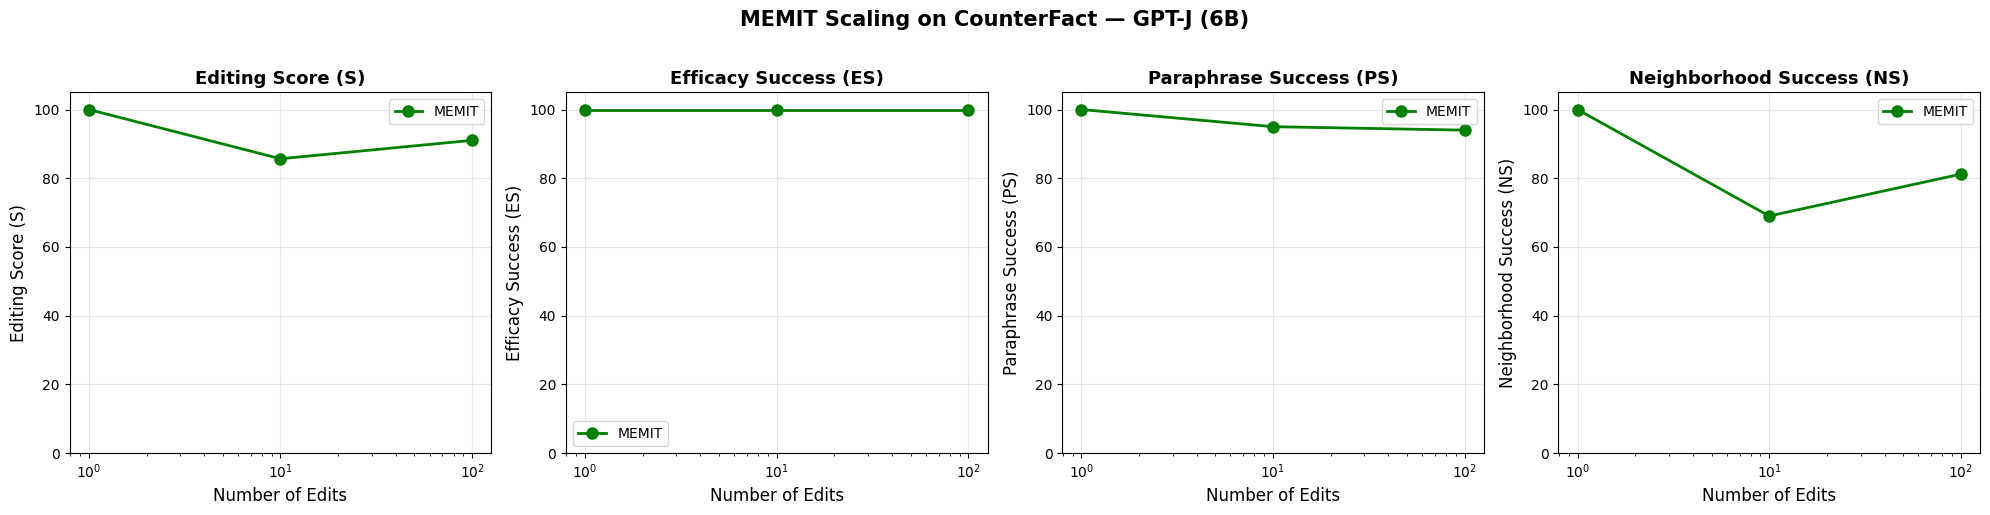

Plot saved to Google Drive: /content/drive/MyDrive/MEMIT_Results/scaling_curves.png


In [ ]:
# ============================================================
# PLOT SCALING CURVES (similar to Figure 5 in the paper)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metric_names = [
    "Editing Score (S)",
    "Efficacy Success (ES)",
    "Paraphrase Success (PS)",
    "Neighborhood Success (NS)",
]

x_vals = sorted(scaling_results.keys())

for ax, metric_name in zip(axes, metric_names):
    y_vals = [scaling_results[n][metric_name] for n in x_vals]
    ax.plot(x_vals, y_vals, 'o-', color='green', linewidth=2, markersize=8, label='MEMIT')
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edits', fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f'MEMIT Scaling on CounterFact — GPT-J (6B)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scaling_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save to Google Drive if mounted
import shutil
try:
    shutil.copy('scaling_curves.png', f'{SAVE_DIR}/scaling_curves.png')
    print(f"Plot saved to Google Drive: {SAVE_DIR}/scaling_curves.png")
except:
    print("Plot saved locally as scaling_curves.png")

## 16. Save Results to Google Drive

In [ ]:
# ============================================================
# SAVE ALL RESULTS
# ============================================================
import json

def make_serializable(obj):
    """Convert numpy/torch types to Python natives for JSON."""
    if isinstance(obj, dict):
        return {str(k): make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_serializable(x) for x in obj]
    elif isinstance(obj, (int, float, str, bool)):
        return obj
    else:
        try:
            return float(obj)
        except (TypeError, ValueError):
            return str(obj)

results_out = {
    "num_edits": NUM_EDITS,
    "model": "EleutherAI/gpt-j-6B",
    "algorithm": "MEMIT",
    "aggregate_metrics": make_serializable(metrics),
    "scaling_results": make_serializable(scaling_results) if 'scaling_results' in dir() else {},
    "num_records_evaluated": len(all_results),
}

# Save locally
with open("counterfact_results.json", "w") as f:
    json.dump(results_out, f, indent=2)

# Save to Google Drive
try:
    import shutil
    shutil.copy("counterfact_results.json", f"{SAVE_DIR}/counterfact_results.json")
    print(f"Results saved to Google Drive: {SAVE_DIR}/counterfact_results.json")
except:
    print("Results saved locally as counterfact_results.json")

print("\nSaved metrics:")
for k, v in results_out["aggregate_metrics"].items():
    if isinstance(v, (int, float)):
        print(f"  {k}: {v:.1f}")
    else:
        print(f"  {k}: {v}")


Results saved to Google Drive: /content/drive/MyDrive/MEMIT_Results/counterfact_results.json

Saved metrics:
  case_id: 106.0
  num_edits: 100.0
  requested_rewrite: {'prompt': "{}'s domain of activity is", 'relation_id': 'P101', 'target_new': {'str': 'mathematics', 'id': 'Q395'}, 'target_true': {'str': 'physics', 'id': 'Q413'}, 'subject': 'John Henry Poynting'}
  post: {'rewrite_prompts_probs': [{'target_new': 0.03438250347971916, 'target_true': 9.253132820129395}], 'paraphrase_prompts_probs': [{'target_new': 0.07702510058879852, 'target_true': 8.045775413513184}, {'target_new': 0.13531528413295746, 'target_true': 9.03375244140625}], 'neighborhood_prompts_probs': [{'target_new': 4.757392883300781, 'target_true': 4.530830383300781}, {'target_new': 7.680384159088135, 'target_true': 8.457727432250977}, {'target_new': 4.619464874267578, 'target_true': 5.471027374267578}, {'target_new': 3.935887336730957, 'target_true': 5.287449836730957}, {'target_new': 7.6755876541137695, 'target_true': 